## Level 2 – Task 1: Regression Analysis
This task involves building a Linear Regression model to predict house prices using multiple features such as crime rate, number of rooms, pollution levels, and other socio-economic factors.

In [5]:
# Import libraries for data handling and machine learning
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# Load the cleaned dataset
df = pd.read_csv('/content/cleaned_house_data (1).csv')

# Preview the dataset
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [7]:
# Check structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## Dataset Overview
The dataset contains 506 observations with 14 features, including both independent variables and the target variable (MEDV). All features are numerical, and there are no missing values, making the dataset suitable for regression analysis.

In [8]:
# Check summary statistics
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [9]:
# Features (independent variables)
X = df.drop('MEDV', axis=1)

# Target variable (dependent variable)
y = df['MEDV']

In [10]:
from sklearn.model_selection import train_test_split

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shape
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (404, 13)
Testing set: (102, 13)


In [11]:
from sklearn.linear_model import LinearRegression

# Initialize model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

In [12]:
# Predict using test data
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 24.291119474973478


In [14]:
# Calculate R² score
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.6687594935356326


## Model Evaluation
The Linear Regression model achieved an R² score of 0.669, indicating that approximately 66.9% of the variance in house prices is explained by the model. The Mean Squared Error (MSE) of 24.29 suggests moderate prediction accuracy, with some deviations between actual and predicted values.

In [15]:
# Create coefficients table
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Sort for better interpretation
coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
5,RM,4.438835
3,CHAS,2.784438
8,RAD,0.262430
2,INDUS,0.040381
1,ZN,0.030110
11,B,0.012351
6,AGE,-0.006296
9,TAX,-0.010647
0,CRIM,-0.113056
12,LSTAT,-0.508571


## Feature Importance Interpretation
The analysis of model coefficients reveals that the number of rooms (RM) has the strongest positive impact on house prices, indicating that larger homes tend to be more valuable. Proximity to the Charles River (CHAS) also positively influences prices.

On the other hand, nitrogen oxide levels (NOX) have the most significant negative impact, suggesting that higher pollution reduces property value. Other negative factors include distance to employment centers (DIS), student-teacher ratio (PTRATIO), and the proportion of lower-income population (LSTAT).

Overall, both environmental and socio-economic factors play a crucial role in determining house prices.

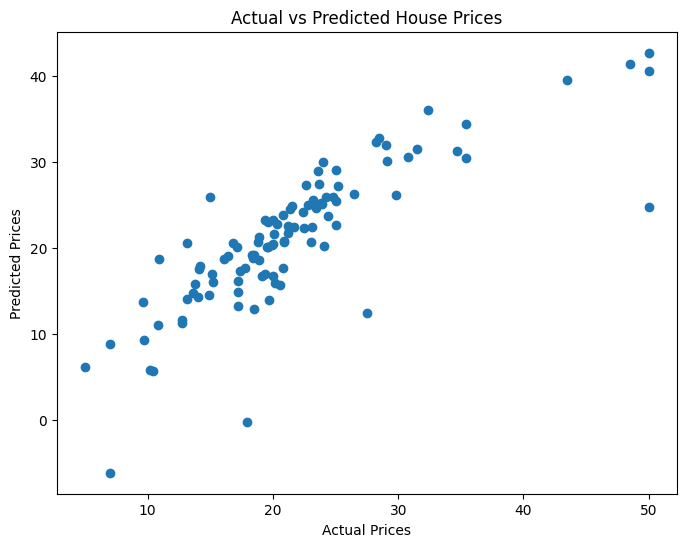

In [16]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Model Visualization Insight
The scatter plot of actual versus predicted values shows a clear positive relationship, indicating that the model captures the general trend in house prices. However, some dispersion around the trend line suggests prediction errors, particularly for higher-priced houses where the model shows less accuracy.

## Final Conclusion
The Linear Regression model demonstrates a moderate ability to predict house prices, capturing key relationships between features and the target variable. While the model performs reasonably well, there is room for improvement, as some variability in house prices remains unexplained. Future improvements could involve using more advanced models or additional features to enhance prediction accuracy.